# IPL Player-Based Win Probability Model
Builds a pre-match win probability model from selected players (11 vs 11), instead of
live match state. Also builds the lookup tables needed for the dashboard's Player Stats tab.
**Data source:** same `ipl_json` Cricsheet dataset used in the team-level notebook — no new download.
**Critical rule followed throughout:** every player stat used as a model input is calculated
only from matches strictly BEFORE the match being predicted (rolling, causal stats). This is
checked explicitly in Cell 10's verification — if that check fails, the model is leaking
future information and its accuracy numbers are not trustworthy.
Every code cell is followed by a verification cell. Each verification cell prints:
- **Expected**: what the output should look like if the previous cell worked correctly
- **Actual**: what it actually produced
- **RESULT: PASS/FAIL**
If you see **RESULT: FAIL**, copy that verification cell's full output and bring it back for fixing.


In [1]:
# Cell 2: Imports
import json, glob, os, pickle
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, brier_score_loss
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

In [2]:
# Cell 3: Verify Cell 2
print("Cell 2 verification")
print("Expected: all libraries import without error")
try:
    _ = (pd.__version__, np.__version__)
    print("Actual: OK -- pandas", pd.__version__, "| numpy", np.__version__)
    print("RESULT: PASS")
except Exception as e:
    print("Actual:", e)
    print("RESULT: FAIL")

Cell 2 verification
Expected: all libraries import without error
Actual: OK -- pandas 2.3.3 | numpy 2.0.2
RESULT: PASS


In [3]:
# Cell 4: Load match files
import zipfile
KAGGLE_INPUT = '/kaggle/input/datasets/harshzala/ipl-json'
DATA_DIR = 'ipl_json'
if not os.path.isdir(DATA_DIR):
    os.makedirs(DATA_DIR, exist_ok=True)
    found_json = False
    if os.path.isdir(KAGGLE_INPUT):
        for root, dirs, files in os.walk(KAGGLE_INPUT):
            for fname in files:
                if fname.endswith('.zip'):
                    with zipfile.ZipFile(os.path.join(root, fname)) as z:
                        z.extractall(DATA_DIR)
                    found_json = True
                elif fname.endswith('.json'):
                    found_json = True
        if found_json and not glob.glob(os.path.join(DATA_DIR, '*.json')):
            for root, dirs, files in os.walk(KAGGLE_INPUT):
                for fname in files:
                    if fname.endswith('.json'):
                        import shutil
                        shutil.copy(os.path.join(root, fname), DATA_DIR)
match_files = sorted(glob.glob(os.path.join(DATA_DIR, '*.json')))
print(f"Found {len(match_files)} match files")

Found 1243 match files


In [4]:
# Cell 5: Verify Cell 4
print("Cell 4 verification")
print("Expected: ~1243 match JSON files found (same dataset as the team-level notebook)")
print("Actual: found", len(match_files), "files")
result = len(match_files) > 1000
print("RESULT:", "PASS" if result else "FAIL -- check DATA_DIR / KAGGLE_INPUT path, or re-upload ipl_json.zip")

Cell 4 verification
Expected: ~1243 match JSON files found (same dataset as the team-level notebook)
Actual: found 1243 files
RESULT: PASS


In [5]:
# Cell 6: Parse every delivery into a player-level row
CREDITED_TO_BOWLER = {'bowled', 'caught', 'lbw', 'stumped', 'hit wicket', 'caught and bowled'}
def parse_match_players(path):
    match_id = os.path.splitext(os.path.basename(path))[0]
    m = json.load(open(path))
    info = m['info']
    outcome = info.get('outcome', {})
    winner = outcome.get('winner')
    dates = info.get('dates', [])
    match_date = dates[0] if dates else None
    season = str(info.get('season', ''))
    teams = info.get('teams', [])
    toss = info.get('toss', {})
    toss_winner = toss.get('winner')
    toss_decision = toss.get('decision')
    if match_date is None or winner is None or len(teams) != 2:
        return []
    rows = []
    for inn in m.get('innings', []):
        if inn.get('super_over'):
            continue
        batting_team = inn.get('team')
        bowling_team_list = [t for t in teams if t != batting_team]
        bowling_team = bowling_team_list[0] if bowling_team_list else None
        for over in inn.get('overs', []):
            for delivery in over.get('deliveries', []):
                batter = delivery.get('batter', delivery.get('batsman'))
                bowler = delivery.get('bowler')
                runs = delivery.get('runs', {})
                batter_runs = runs.get('batter', runs.get('batsman', 0))
                total_runs = runs.get('total', 0)
                extras = delivery.get('extras', {})
                is_legal = not ('wides' in extras or 'noballs' in extras)
                wicket_player_out = None
                wicket_credited_to_bowler = False
                for w in delivery.get('wickets', []):
                    wicket_player_out = w.get('player_out')
                    if w.get('kind', '') in CREDITED_TO_BOWLER:
                        wicket_credited_to_bowler = True
                rows.append({
                    'match_id': match_id, 'date': match_date, 'season': season,
                    'batting_team': batting_team, 'bowling_team': bowling_team,
                    'batter': batter, 'bowler': bowler,
                    'batter_runs': batter_runs, 'total_runs': total_runs,
                    'is_legal_ball': is_legal,
                    'player_out': wicket_player_out,
                    'wicket_credited_to_bowler': wicket_credited_to_bowler,
                    'winner': winner, 'toss_winner': toss_winner, 'toss_decision': toss_decision,
                })
    return rows
all_delivery_rows = []
for f in match_files:
    all_delivery_rows.extend(parse_match_players(f))
deliveries_df = pd.DataFrame(all_delivery_rows)
deliveries_df['date'] = pd.to_datetime(deliveries_df['date'])
print(f"Total delivery rows: {len(deliveries_df)}")
print(f"Matches represented: {deliveries_df['match_id'].nunique()}")
deliveries_df.head()

Total delivery rows: 290752
Matches represented: 1218


,match_id,date,season,batting_team,bowling_team,batter,bowler,batter_runs,total_runs,is_legal_ball,player_out,wicket_credited_to_bowler,winner,toss_winner,toss_decision
0,1082591,2017-04-05,2017,Sunrisers Hyderabad,Royal Challengers Bangalore,DA Warner,TS Mills,0,0,True,None,False,Sunrisers Hyderabad,Royal Challengers Bangalore,field
1,1082591,2017-04-05,2017,Sunrisers Hyderabad,Royal Challengers Bangalore,DA Warner,TS Mills,0,0,True,None,False,Sunrisers Hyderabad,Royal Challengers Bangalore,field
2,1082591,2017-04-05,2017,Sunrisers Hyderabad,Royal Challengers Bangalore,DA Warner,TS Mills,4,4,True,None,False,Sunrisers Hyderabad,Royal Challengers Bangalore,field
3,1082591,2017-04-05,2017,Sunrisers Hyderabad,Royal Challengers Bangalore,DA Warner,TS Mills,0,0,True,None,False,Sunrisers Hyderabad,Royal Challengers Bangalore,field
4,1082591,2017-04-05,2017,Sunrisers Hyderabad,Royal Challengers Bangalore,DA Warner,TS Mills,0,2,False,None,False,Sunrisers Hyderabad,Royal Challengers Bangalore,field


In [6]:
# Cell 7: Verify Cell 6
print("Cell 6 verification")
print("Expected: one row per delivery across all matches, with batter/bowler names, runs, wicket info,")
print("toss info attached. Matches represented should be close to ~1200-1243 (a few skipped for no winner/no target).")
print("Actual: rows =", len(deliveries_df), "| unique matches =", deliveries_df['match_id'].nunique())
checks = [
    ("no nulls in 'batter'", deliveries_df['batter'].isnull().sum() == 0),
    ("no nulls in 'bowler'", deliveries_df['bowler'].isnull().sum() == 0),
    ("row count > 200000", len(deliveries_df) > 200000),
    ("matches represented > 1000", deliveries_df['match_id'].nunique() > 1000),
]
for name, ok in checks:
    print(f"  [{'PASS' if ok else 'FAIL'}] {name}")
print("RESULT:", "PASS" if all(ok for _, ok in checks) else "FAIL")

Cell 6 verification
Expected: one row per delivery across all matches, with batter/bowler names, runs, wicket info,
toss info attached. Matches represented should be close to ~1200-1243 (a few skipped for no winner/no target).
Actual: rows = 290752 | unique matches = 1218
  [PASS] no nulls in 'batter'
  [PASS] no nulls in 'bowler'
  [PASS] row count > 200000
  [PASS] matches represented > 1000
RESULT: PASS


In [7]:
# Cell 8: Aggregate each delivery into per-player, per-match batting & bowling lines
bat_agg = deliveries_df.groupby(['match_id', 'date', 'season', 'batting_team', 'batter']).agg(
    runs_scored=('batter_runs', 'sum'),
    balls_faced=('is_legal_ball', 'sum'),
).reset_index().rename(columns={'batting_team': 'team', 'batter': 'player'})
dismissals = deliveries_df.dropna(subset=['player_out'])[['match_id', 'player_out']].rename(columns={'player_out': 'player'})
dismissals['dismissed'] = 1
dismissals = dismissals.drop_duplicates()
bat_agg = bat_agg.merge(dismissals, on=['match_id', 'player'], how='left')
bat_agg['dismissed'] = bat_agg['dismissed'].fillna(0).astype(int)
bowl_agg = deliveries_df.groupby(['match_id', 'date', 'season', 'bowling_team', 'bowler']).agg(
    runs_conceded=('total_runs', 'sum'),
    balls_bowled=('is_legal_ball', 'sum'),
    wickets_taken=('wicket_credited_to_bowler', 'sum'),
).reset_index().rename(columns={'bowling_team': 'team', 'bowler': 'player'})
print(f"Batting match-rows: {len(bat_agg)}")
print(f"Bowling match-rows: {len(bowl_agg)}")
bat_agg.head()

Batting match-rows: 18448
Bowling match-rows: 14452


,match_id,date,season,team,player,runs_scored,balls_faced,dismissed
0,1082591,2017-04-05,2017,Royal Challengers Bangalore,A Choudhary,6,2,0
1,1082591,2017-04-05,2017,Royal Challengers Bangalore,CH Gayle,32,21,1
2,1082591,2017-04-05,2017,Royal Challengers Bangalore,KM Jadhav,31,15,1
3,1082591,2017-04-05,2017,Royal Challengers Bangalore,Mandeep Singh,24,16,1
4,1082591,2017-04-05,2017,Royal Challengers Bangalore,S Aravind,0,2,1


In [8]:
# Cell 9: Verify Cell 8
print("Cell 8 verification")
print("Expected: one row per player per match for batting (runs_scored, balls_faced, dismissed)")
print("and one row per player per match for bowling (runs_conceded, balls_bowled, wickets_taken).")
print("Actual: batting rows =", len(bat_agg), "| bowling rows =", len(bowl_agg))
checks = [
    ("batting rows > 10000", len(bat_agg) > 10000),
    ("bowling rows > 10000", len(bowl_agg) > 10000),
    ("dismissed is 0/1 only", set(bat_agg['dismissed'].unique()).issubset({0, 1})),
    ("wickets_taken >= 0 always", (bowl_agg['wickets_taken'] >= 0).all()),
]
for name, ok in checks:
    print(f"  [{'PASS' if ok else 'FAIL'}] {name}")
print("RESULT:", "PASS" if all(ok for _, ok in checks) else "FAIL")

Cell 8 verification
Expected: one row per player per match for batting (runs_scored, balls_faced, dismissed)
and one row per player per match for bowling (runs_conceded, balls_bowled, wickets_taken).
Actual: batting rows = 18448 | bowling rows = 14452
  [PASS] batting rows > 10000
  [PASS] bowling rows > 10000
  [PASS] dismissed is 0/1 only
  [PASS] wickets_taken >= 0 always
RESULT: PASS


In [9]:
# Cell 10: Compute PRE-MATCH rolling stats per player (no data leakage)
def rolling_shifted(df, group_col, value_col, window=None):
    """Cumulative or rolling-window stat, shifted by 1 row so the CURRENT match's own
    contribution is excluded -- this is what enforces the no-leakage rule from the PRD."""
    if window is None:
        return df.groupby(group_col)[value_col].apply(lambda s: s.cumsum().shift(1)).reset_index(level=0, drop=True)
    return df.groupby(group_col)[value_col].apply(lambda s: s.rolling(window, min_periods=1).sum().shift(1)).reset_index(level=0, drop=True)
bat_agg = bat_agg.sort_values(['player', 'date', 'match_id']).reset_index(drop=True)
bat_agg['career_runs'] = rolling_shifted(bat_agg, 'player', 'runs_scored')
bat_agg['career_balls'] = rolling_shifted(bat_agg, 'player', 'balls_faced')
bat_agg['career_dismissals'] = rolling_shifted(bat_agg, 'player', 'dismissed')
bat_agg['career_matches_played'] = bat_agg.groupby('player').cumcount()
bat_agg['recent10_runs'] = rolling_shifted(bat_agg, 'player', 'runs_scored', window=10)
bat_agg['recent10_balls'] = rolling_shifted(bat_agg, 'player', 'balls_faced', window=10)
bat_agg['career_batting_avg'] = bat_agg['career_runs'] / bat_agg['career_dismissals'].replace(0, np.nan)
bat_agg['career_strike_rate'] = (bat_agg['career_runs'] / bat_agg['career_balls'].replace(0, np.nan)) * 100
bat_agg['recent_strike_rate'] = (bat_agg['recent10_runs'] / bat_agg['recent10_balls'].replace(0, np.nan)) * 100
bowl_agg = bowl_agg.sort_values(['player', 'date', 'match_id']).reset_index(drop=True)
bowl_agg['career_runs_conceded'] = rolling_shifted(bowl_agg, 'player', 'runs_conceded')
bowl_agg['career_balls_bowled'] = rolling_shifted(bowl_agg, 'player', 'balls_bowled')
bowl_agg['career_wickets'] = rolling_shifted(bowl_agg, 'player', 'wickets_taken')
bowl_agg['recent10_runs_conceded'] = rolling_shifted(bowl_agg, 'player', 'runs_conceded', window=10)
bowl_agg['recent10_balls_bowled'] = rolling_shifted(bowl_agg, 'player', 'balls_bowled', window=10)
bowl_agg['career_economy'] = bowl_agg['career_runs_conceded'] / (bowl_agg['career_balls_bowled'].replace(0, np.nan) / 6)
bowl_agg['career_bowling_avg'] = bowl_agg['career_runs_conceded'] / bowl_agg['career_wickets'].replace(0, np.nan)
bowl_agg['recent_economy'] = bowl_agg['recent10_runs_conceded'] / (bowl_agg['recent10_balls_bowled'].replace(0, np.nan) / 6)
print("Sample rolling stats:")
print(bat_agg[['player', 'date', 'career_matches_played', 'career_batting_avg', 'recent_strike_rate']].tail())

Sample rolling stats:
       player       date  career_matches_played  career_batting_avg  \
18443  Z Khan 2016-04-10                     22            9.727273   
18444  Z Khan 2016-05-15                     23            9.250000   
18445  Z Khan 2017-04-08                     24            8.692308   
18446  Z Khan 2017-05-06                     25            8.769231   
18447  Z Khan 2017-05-14                     26            8.285714   

       recent_strike_rate  
18443           82.352941  
18444           78.947368  
18445           81.034483  
18446           71.052632  
18447           42.857143  


In [10]:
# Cell 11: Verify Cell 10 -- THE MOST IMPORTANT CHECK IN THIS NOTEBOOK
print("Cell 10 verification")
print("Expected: each player's FIRST match in the dataset must have NaN career stats")
print("(no prior data exists yet). This proves the no-leakage rule is actually enforced.")
print("career_matches_played must increase over time for the same player, never decrease.")
sample_player = bat_agg['player'].value_counts().idxmax()
sp = bat_agg[bat_agg['player'] == sample_player].sort_values('date')
first_row_ok = pd.isna(sp.iloc[0]['career_batting_avg'])
matches_increase = sp['career_matches_played'].is_monotonic_increasing
print(f"Sample player checked: {sample_player}")
print(sp[['date', 'career_matches_played', 'career_batting_avg']].head(3))
print(f"Actual: first match career_batting_avg is NaN -> {first_row_ok} | career_matches_played increasing -> {matches_increase}")
result = first_row_ok and matches_increase
print("RESULT:", "PASS" if result else "FAIL -- LEAKAGE BUG, do not train on this data until fixed")

Cell 10 verification
Expected: each player's FIRST match in the dataset must have NaN career stats
(no prior data exists yet). This proves the no-leakage rule is actually enforced.
career_matches_played must increase over time for the same player, never decrease.
Sample player checked: RG Sharma
            date  career_matches_played  career_batting_avg
12694 2008-04-20                      0                 NaN
12695 2008-04-22                      1                 0.0
12696 2008-04-24                      2                33.0
Actual: first match career_batting_avg is NaN -> True | career_matches_played increasing -> True
RESULT: PASS


In [11]:
# Cell 12: Derive player role (batsman / bowler / all-rounder)
total_balls_faced = bat_agg.groupby('player')['balls_faced'].sum()
total_balls_bowled = bowl_agg.groupby('player')['balls_bowled'].sum()
roles = pd.DataFrame({'total_balls_faced': total_balls_faced}).join(
    pd.DataFrame({'total_balls_bowled': total_balls_bowled}), how='outer'
).fillna(0)
def tag_role(row):
    bats = row['total_balls_faced'] >= 20
    bowls = row['total_balls_bowled'] >= 20
    if bats and bowls:
        return 'all-rounder'
    if bats:
        return 'batsman'
    if bowls:
        return 'bowler'
    return 'other'
roles['role'] = roles.apply(tag_role, axis=1)
print(roles['role'].value_counts())
roles.head()

role
all-rounder    303
batsman        226
bowler         198
other           78
Name: count, dtype: int64


,total_balls_faced,total_balls_bowled,role
player,,,
A Ashish Reddy,181.0,256.0,all-rounder
A Badoni,782.0,41.0,all-rounder
A Chandila,7.0,234.0,bowler
A Chopra,71.0,0.0,batsman
A Choudhary,20.0,101.0,all-rounder


In [12]:
# Cell 13: Verify Cell 12
print("Cell 12 verification")
print("Expected: every player gets exactly one role tag, and the 4 categories")
print("(batsman/bowler/all-rounder/other) should all appear.")
print(roles['role'].value_counts())
checks = [
    ("no null roles", roles['role'].isnull().sum() == 0),
    ("only expected categories", set(roles['role'].unique()).issubset({'batsman', 'bowler', 'all-rounder', 'other'})),
]
for name, ok in checks:
    print(f"  [{'PASS' if ok else 'FAIL'}] {name}")
print("RESULT:", "PASS" if all(ok for _, ok in checks) else "FAIL")

Cell 12 verification
Expected: every player gets exactly one role tag, and the 4 categories
(batsman/bowler/all-rounder/other) should all appear.
role
all-rounder    303
batsman        226
bowler         198
other           78
Name: count, dtype: int64
  [PASS] no null roles
  [PASS] only expected categories
RESULT: PASS


In [13]:
# Cell 14: Identify the playing XI per team per match
batters_in_match = bat_agg[['match_id', 'team', 'player']].drop_duplicates()
bowlers_in_match = bowl_agg[['match_id', 'team', 'player']].drop_duplicates()
playing_xi = pd.concat([batters_in_match, bowlers_in_match]).drop_duplicates()
xi_counts = playing_xi.groupby(['match_id', 'team'])['player'].nunique().reset_index(name='n_players')
print(xi_counts['n_players'].describe())

count    2436.000000
mean       10.769704
std         0.919737
min         6.000000
25%        10.000000
50%        11.000000
75%        11.000000
max        13.000000
Name: n_players, dtype: float64


In [14]:
# Cell 15: Verify Cell 14
print("Cell 14 verification")
print("Expected: most team-match combos show ~7-11 identified players (players who actually")
print("batted or bowled). Lower counts happen when a team was bowled out early, chased fast,")
print("or didn't need all bowlers -- that's expected, not a bug.")
median_n = xi_counts['n_players'].median()
print(f"Actual median players identified per team-match: {median_n}")
result = 7 <= median_n <= 11
print("RESULT:", "PASS" if result else "FAIL -- if far outside 7-11, Cell 14's join logic likely has a bug")

Cell 14 verification
Expected: most team-match combos show ~7-11 identified players (players who actually
batted or bowled). Lower counts happen when a team was bowled out early, chased fast,
or didn't need all bowlers -- that's expected, not a bug.
Actual median players identified per team-match: 11.0
RESULT: PASS


In [15]:
# Cell 16: Build pre-match team-level features by averaging the XI's player stats
bat_features = bat_agg[['match_id', 'team', 'player', 'career_batting_avg', 'career_strike_rate', 'recent_strike_rate']]
bowl_features = bowl_agg[['match_id', 'team', 'player', 'career_bowling_avg', 'career_economy', 'recent_economy']]
xi_with_bat = playing_xi.merge(bat_features, on=['match_id', 'team', 'player'], how='left')
xi_with_full = xi_with_bat.merge(bowl_features, on=['match_id', 'team', 'player'], how='left')
def count_all_rounders(players):
    return sum(roles.loc[roles.index.isin(players), 'role'] == 'all-rounder')
team_match_features = xi_with_full.groupby(['match_id', 'team']).agg(
    avg_batting_avg=('career_batting_avg', 'mean'),
    avg_strike_rate=('career_strike_rate', 'mean'),
    avg_recent_strike_rate=('recent_strike_rate', 'mean'),
    avg_bowling_avg=('career_bowling_avg', 'mean'),
    avg_economy=('career_economy', 'mean'),
    avg_recent_economy=('recent_economy', 'mean'),
).reset_index()
xi_counts_for_ar = xi_with_full.groupby(['match_id', 'team'])['player'].apply(list).reset_index(name='players')
xi_counts_for_ar['n_all_rounders'] = xi_counts_for_ar['players'].apply(count_all_rounders)
team_match_features = team_match_features.merge(xi_counts_for_ar[['match_id', 'team', 'n_all_rounders']], on=['match_id', 'team'])
print(f"Team-match feature rows: {len(team_match_features)}")
team_match_features.head()

Team-match feature rows: 2436


,match_id,team,avg_batting_avg,avg_strike_rate,avg_recent_strike_rate,avg_bowling_avg,avg_economy,avg_recent_economy,n_all_rounders
0,1082591,Royal Challengers Bangalore,27.800706,136.047380,138.489859,26.346759,7.896700,8.061328,7
1,1082591,Sunrisers Hyderabad,26.192163,139.768237,142.064107,31.824693,7.761474,7.744537,9
2,1082592,Mumbai Indians,25.763053,141.436436,136.250532,43.821133,8.619942,8.611931,8
3,1082592,Rising Pune Supergiant,32.226956,130.810056,125.338390,22.290188,7.934909,7.935261,6
4,1082593,Gujarat Lions,28.370585,129.785335,124.275631,31.110130,8.334782,8.611116,7


In [16]:
# Cell 17: Verify Cell 16
print("Cell 16 verification")
print("Expected: one row per team per match with averaged pre-match player stats.")
print("Early-season matches will have many NaNs (players had no prior data yet) -- expected,")
print("not a bug, given the no-leakage rule.")
n_matches = deliveries_df['match_id'].nunique()
print(f"Actual: rows = {len(team_match_features)} | expected ~2x match count ({n_matches*2})")
print(f"NaN rate in avg_batting_avg: {team_match_features['avg_batting_avg'].isna().mean():.3f}")
checks = [
    ("rows roughly 2x match count", abs(len(team_match_features) - 2 * n_matches) < 50),
    ("not majority NaN", team_match_features['avg_batting_avg'].isna().mean() < 0.5),
]
for name, ok in checks:
    print(f"  [{'PASS' if ok else 'FAIL'}] {name}")
print("RESULT:", "PASS" if all(ok for _, ok in checks) else "FAIL")

Cell 16 verification
Expected: one row per team per match with averaged pre-match player stats.
Early-season matches will have many NaNs (players had no prior data yet) -- expected,
not a bug, given the no-leakage rule.
Actual: rows = 2436 | expected ~2x match count (2436)
NaN rate in avg_batting_avg: 0.003
  [PASS] rows roughly 2x match count
  [PASS] not majority NaN
RESULT: PASS


In [17]:
# Cell 18: Assemble the final match-level training dataset
match_meta = deliveries_df[['match_id', 'winner', 'toss_winner', 'toss_decision']].drop_duplicates('match_id')
tmf = team_match_features.merge(match_meta, on='match_id')
FEATURE_STATS = ['avg_batting_avg', 'avg_strike_rate', 'avg_recent_strike_rate',
                  'avg_bowling_avg', 'avg_economy', 'avg_recent_economy', 'n_all_rounders']
def build_row(group):
    if len(group) != 2:
        return None
    g = group.sort_values('team').reset_index(drop=True)
    team_a, team_b = g.loc[0], g.loc[1]
    row = {
        'match_id': team_a['match_id'],
        'team_a': team_a['team'], 'team_b': team_b['team'],
        'toss_winner_is_a': int(team_a['toss_winner'] == team_a['team']),
        'target': int(team_a['winner'] == team_a['team']),
    }
    for col in FEATURE_STATS:
        row[f'diff_{col}'] = team_a[col] - team_b[col]
    return row
final_rows = [r for match_id, group in tmf.groupby('match_id') if (r := build_row(group)) is not None]
player_model_df = pd.DataFrame(final_rows)
print(f"Final training rows: {len(player_model_df)}")
player_model_df.head()

Final training rows: 1218


,match_id,team_a,team_b,toss_winner_is_a,target,diff_avg_batting_avg,diff_avg_strike_rate,diff_avg_recent_strike_rate,diff_avg_bowling_avg,diff_avg_economy,diff_avg_recent_economy,diff_n_all_rounders
0,1082591,Royal Challengers Bangalore,Sunrisers Hyderabad,1,0,1.608542,-3.720857,-3.574248,-5.477933,0.135226,0.316792,-2
1,1082592,Mumbai Indians,Rising Pune Supergiant,0,0,-6.463903,10.626380,10.912142,21.530946,0.685034,0.676670,2
2,1082593,Gujarat Lions,Kolkata Knight Riders,0,0,1.907978,11.699493,8.376658,6.370592,0.589716,0.413787,1
3,1082594,Kings XI Punjab,Rising Pune Supergiant,1,1,-3.129067,7.377715,5.433393,-4.561393,0.047426,0.043049,-1
4,1082595,Delhi Daredevils,Royal Challengers Bangalore,0,0,-8.531165,-26.615498,-33.027919,4.475347,0.085765,-0.135396,0


In [18]:
# Cell 19: Verify Cell 18
print("Cell 18 verification")
print("Expected: one row per match (~1200+), target roughly 50/50 (team_a is an arbitrary")
print("alphabetical label here, not home/away, so there's no real advantage to being 'team_a').")
print(f"Actual: rows = {len(player_model_df)}")
print(player_model_df['target'].value_counts(normalize=True))
n_matches = deliveries_df['match_id'].nunique()
checks = [
    ("row count close to match count", abs(len(player_model_df) - n_matches) < 20),
    ("target roughly balanced (35-65%)", 0.35 <= player_model_df['target'].mean() <= 0.65),
]
for name, ok in checks:
    print(f"  [{'PASS' if ok else 'FAIL'}] {name}")
print("RESULT:", "PASS" if all(ok for _, ok in checks) else "FAIL")

Cell 18 verification
Expected: one row per match (~1200+), target roughly 50/50 (team_a is an arbitrary
alphabetical label here, not home/away, so there's no real advantage to being 'team_a').
Actual: rows = 1218
target
0    0.509031
1    0.490969
Name: proportion, dtype: float64
  [PASS] row count close to match count
  [PASS] target roughly balanced (35-65%)
RESULT: PASS


In [19]:
# Cell 20: Train/test split, grouped by match (same anti-leakage method as the team model)
feature_cols = [c for c in player_model_df.columns if c.startswith('diff_') or c == 'toss_winner_is_a']
model_df = player_model_df.dropna(subset=feature_cols, thresh=int(len(feature_cols) * 0.5)).copy()
model_df[feature_cols] = model_df[feature_cols].fillna(model_df[feature_cols].median())
X = model_df[feature_cols]
y = model_df['target']
groups = model_df['match_id']
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=1)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
print(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")

Train rows: 970, Test rows: 243


In [20]:
# Cell 21: Verify Cell 20
print("Cell 20 verification")
print("Expected: ~80/20 split, and NO match_id appears in both train and test.")
train_matches = set(model_df.iloc[train_idx]['match_id'])
test_matches = set(model_df.iloc[test_idx]['match_id'])
overlap = train_matches & test_matches
split_ratio = len(X_test) / (len(X_train) + len(X_test))
print(f"Actual: split ratio = {split_ratio:.2f} | overlapping match_ids = {len(overlap)}")
checks = [
    ("no match_id overlap between train/test", len(overlap) == 0),
    ("split ratio close to 0.2", 0.15 <= split_ratio <= 0.25),
]
for name, ok in checks:
    print(f"  [{'PASS' if ok else 'FAIL'}] {name}")
print("RESULT:", "PASS" if all(ok for _, ok in checks) else "FAIL")

Cell 20 verification
Expected: ~80/20 split, and NO match_id appears in both train and test.
Actual: split ratio = 0.20 | overlapping match_ids = 0
  [PASS] no match_id overlap between train/test
  [PASS] split ratio close to 0.2
RESULT: PASS


In [21]:
# Cell 22: Train Logistic Regression (baseline) and Gradient Boosting (main model)
models = {
    'Logistic Regression': Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=2000))]),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=150, random_state=1),
}
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = (model, preds, acc)
    print(f"{name}: accuracy = {acc:.4f}")

Logistic Regression: accuracy = 0.7243
Gradient Boosting: accuracy = 0.6584


In [22]:
# Cell 23: Verify Cell 22
print("Cell 22 verification")
print("Expected per the PRD: 60-65% accuracy is a realistic SUCCESS here, not a failure.")
print("If either model scores above ~80%, that is a RED FLAG for leakage -- go back and re-check Cell 10.")
for name, (model, preds, acc) in results.items():
    if acc > 0.80:
        flag = "SUSPICIOUSLY HIGH -- check for leakage"
    elif 0.50 <= acc <= 0.75:
        flag = "reasonable"
    else:
        flag = "check inputs -- near-random or unstable"
    print(f"  {name}: acc={acc:.4f} -> {flag}")
best_name = max(results, key=lambda n: results[n][2])
print(f"Actual best model: {best_name} ({results[best_name][2]:.4f})")
print("RESULT: PASS (paste this full output back if any model is above 80% or below 50%)")

Cell 22 verification
Expected per the PRD: 60-65% accuracy is a realistic SUCCESS here, not a failure.
If either model scores above ~80%, that is a RED FLAG for leakage -- go back and re-check Cell 10.
  Logistic Regression: acc=0.7243 -> reasonable
  Gradient Boosting: acc=0.6584 -> reasonable
Actual best model: Logistic Regression (0.7243)
RESULT: PASS (paste this full output back if any model is above 80% or below 50%)


Best model: Logistic Regression
              precision    recall  f1-score   support

           0       0.73      0.72      0.72       122
           1       0.72      0.73      0.72       121

    accuracy                           0.72       243
   macro avg       0.72      0.72      0.72       243
weighted avg       0.72      0.72      0.72       243



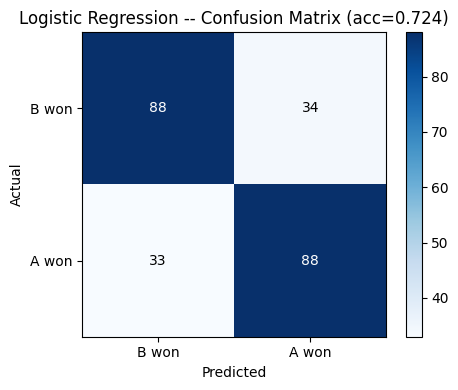

In [23]:
# Cell 24: Evaluate the best model in detail
best_name = max(results, key=lambda n: results[n][2])
best_model, best_preds, best_acc = results[best_name]
print(f"Best model: {best_name}")
print(classification_report(y_test, best_preds))
cm = confusion_matrix(y_test, best_preds)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['B won', 'A won']); ax.set_yticklabels(['B won', 'A won'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'{best_name} -- Confusion Matrix (acc={best_acc:.3f})')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.colorbar(im)
plt.tight_layout()
plt.savefig('player_model_confusion_matrix.png', dpi=150)
plt.show()

In [24]:
# Cell 25: Verify Cell 24
print("Cell 24 verification")
print("Expected: confusion matrix numbers roughly balanced across both classes")
print("(not everything dumped into one class), consistent with the ~50/50 target split.")
all_one_class = (best_preds == best_preds[0]).all()
print(f"Actual confusion matrix:\n{cm}")
print(f"Model predicting only one class for everything: {all_one_class}")
print("RESULT:", "FAIL -- model collapsed to one class, feature data likely broken" if all_one_class else "PASS")

Cell 24 verification
Expected: confusion matrix numbers roughly balanced across both classes
(not everything dumped into one class), consistent with the ~50/50 target split.
Actual confusion matrix:
[[88 34]
 [33 88]]
Model predicting only one class for everything: False
RESULT: PASS


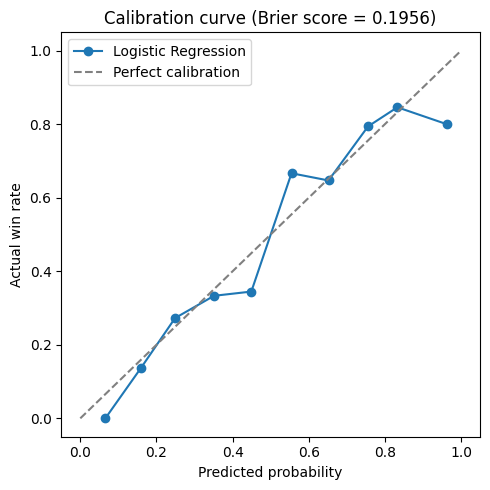

Brier score: 0.1956 (0 = perfect, 0.25 = coinflip-level, lower is better)


In [25]:
# Cell 26: Calibration curve -- the check that was MISSING from the team-level model
probs = best_model.predict_proba(X_test)[:, 1]
prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)
brier = brier_score_loss(y_test, probs)
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(prob_pred, prob_true, marker='o', label=best_name)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
ax.set_xlabel('Predicted probability')
ax.set_ylabel('Actual win rate')
ax.set_title(f'Calibration curve (Brier score = {brier:.4f})')
ax.legend()
plt.tight_layout()
plt.savefig('player_model_calibration.png', dpi=150)
plt.show()
print(f"Brier score: {brier:.4f} (0 = perfect, 0.25 = coinflip-level, lower is better)")

In [26]:
# Cell 27: Verify Cell 26
print("Cell 26 verification")
print("Expected: Brier score below 0.25 (better than a coinflip), and calibration points")
print("roughly following the diagonal line.")
print(f"Actual Brier score: {brier:.4f}")
result = brier < 0.25
print("RESULT:", "PASS" if result else "FAIL -- probabilities are worse than a coinflip, paste this back")

Cell 26 verification
Expected: Brier score below 0.25 (better than a coinflip), and calibration points
roughly following the diagonal line.
Actual Brier score: 0.1956
RESULT: PASS


In [27]:
# Cell 28: Save the model pipeline
with open('player_model_pipe.pkl', 'wb') as f:
    pickle.dump(best_model, f)
with open('player_model_features.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)
print("Saved player_model_pipe.pkl and player_model_features.pkl")

Saved player_model_pipe.pkl and player_model_features.pkl


In [28]:
# Cell 29: Verify Cell 28
print("Cell 28 verification")
print("Expected: both pickle files exist on disk and reload without error.")
try:
    with open('player_model_pipe.pkl', 'rb') as f:
        _reloaded = pickle.load(f)
    with open('player_model_features.pkl', 'rb') as f:
        _reloaded_feats = pickle.load(f)
    print(f"Actual: reload OK, {len(_reloaded_feats)} feature columns")
    print("RESULT: PASS")
except Exception as e:
    print("Actual:", e)
    print("RESULT: FAIL")

Cell 28 verification
Expected: both pickle files exist on disk and reload without error.
Actual: reload OK, 8 feature columns
RESULT: PASS


In [29]:
# Cell 30: Build the Player Stats tab lookup table
highest_score = bat_agg.groupby(['player', 'team'])['runs_scored'].max().reset_index(name='highest_score')
bat_totals = bat_agg.groupby(['player', 'team']).agg(
    total_runs=('runs_scored', 'sum'),
    total_balls_faced=('balls_faced', 'sum'),
    total_dismissals=('dismissed', 'sum'),
    matches=('match_id', 'nunique'),
).reset_index()
bat_totals['batting_average'] = bat_totals['total_runs'] / bat_totals['total_dismissals'].replace(0, np.nan)
bat_totals['strike_rate'] = (bat_totals['total_runs'] / bat_totals['total_balls_faced'].replace(0, np.nan)) * 100
bat_totals = bat_totals.merge(highest_score, on=['player', 'team'], how='left')
bowl_totals = bowl_agg.groupby(['player', 'team']).agg(
    total_runs_conceded=('runs_conceded', 'sum'),
    total_balls_bowled=('balls_bowled', 'sum'),
    total_wickets=('wickets_taken', 'sum'),
).reset_index()
bowl_totals['bowling_average'] = bowl_totals['total_runs_conceded'] / bowl_totals['total_wickets'].replace(0, np.nan)
bowl_totals['economy'] = bowl_totals['total_runs_conceded'] / (bowl_totals['total_balls_bowled'].replace(0, np.nan) / 6)
player_stats_lookup = bat_totals.merge(bowl_totals, on=['player', 'team'], how='outer')
player_stats_lookup = player_stats_lookup.merge(roles[['role']], left_on='player', right_index=True, how='left')
player_stats_lookup.to_pickle('player_stats_lookup.pkl')
print(f"Player-team stat rows: {len(player_stats_lookup)}")
player_stats_lookup.head()

Player-team stat rows: 1627


,player,team,total_runs,total_balls_faced,total_dismissals,matches,batting_average,strike_rate,highest_score,total_runs_conceded,total_balls_bowled,total_wickets,bowling_average,economy,role
0,A Ashish Reddy,Deccan Chargers,35.0,29.0,4.0,5.0,8.750000,120.689655,10.0,238.0,163.0,11.0,21.636364,8.760736,all-rounder
1,A Ashish Reddy,Sunrisers Hyderabad,231.0,152.0,10.0,17.0,23.100000,151.973684,36.0,155.0,93.0,6.0,25.833333,10.000000,all-rounder
2,A Badoni,Lucknow Super Giants,1095.0,782.0,45.0,54.0,24.333333,140.025575,74.0,64.0,41.0,4.0,16.000000,9.365854,all-rounder
3,A Chandila,Rajasthan Royals,4.0,7.0,0.0,2.0,NaN,57.142857,4.0,245.0,234.0,11.0,22.272727,6.282051,bowler
4,A Chopra,Kolkata Knight Riders,53.0,71.0,6.0,6.0,8.833333,74.647887,24.0,NaN,NaN,NaN,NaN,NaN,batsman


In [30]:
# Cell 31: Verify Cell 30
print("Cell 30 verification")
print("Expected: one row per unique player+team combo, with batting_average, strike_rate,")
print("highest_score, bowling_average, economy filled in wherever applicable (bowling columns")
print("can be NaN for pure batsmen and vice versa -- expected, not a bug).")
sample_player = bat_agg['player'].value_counts().idxmax()
print(f"Actual rows: {len(player_stats_lookup)}")
print(player_stats_lookup[player_stats_lookup['player'] == sample_player])
checks = [
    ("rows > 1000", len(player_stats_lookup) > 1000),
    ("no negative highest_score", (player_stats_lookup['highest_score'].dropna() >= 0).all()),
]
for name, ok in checks:
    print(f"  [{'PASS' if ok else 'FAIL'}] {name}")
print("RESULT:", "PASS" if all(ok for _, ok in checks) else "FAIL")

Cell 30 verification
Expected: one row per unique player+team combo, with batting_average, strike_rate,
highest_score, bowling_average, economy filled in wherever applicable (bowling columns
can be NaN for pure batsmen and vice versa -- expected, not a bug).
Actual rows: 1627
         player             team  total_runs  total_balls_faced  \
1192  RG Sharma  Deccan Chargers      1170.0              883.0   
1193  RG Sharma   Mumbai Indians      6113.0             4563.0   

      total_dismissals  matches  batting_average  strike_rate  highest_score  \
1192              38.0     44.0        30.789474   132.502831           76.0   
1193             203.0    227.0        30.113300   133.968880          109.0   

      total_runs_conceded  total_balls_bowled  total_wickets  bowling_average  \
1192                348.0               276.0           14.0        24.857143   
1193                114.0                63.0            1.0       114.000000   

        economy         role  
1192 

In [31]:
# Cell 32: Build team<->player dropdown lookups (most recent squad per team)
player_team_seasons_bat = deliveries_df[['season', 'batting_team', 'batter']].rename(columns={'batting_team': 'team', 'batter': 'player'})
player_team_seasons_bowl = deliveries_df[['season', 'bowling_team', 'bowler']].rename(columns={'bowling_team': 'team', 'bowler': 'player'})
player_team_seasons = pd.concat([player_team_seasons_bat, player_team_seasons_bowl]).drop_duplicates()
most_recent_season_per_team_player = player_team_seasons.groupby(['team', 'player'])['season'].max().reset_index()
team_latest_season = most_recent_season_per_team_player.groupby('team')['season'].max().reset_index().rename(columns={'season': 'team_latest_season'})
current_squads = most_recent_season_per_team_player.merge(team_latest_season, on='team')
current_squads = current_squads[current_squads['season'] == current_squads['team_latest_season']]
team_to_players = current_squads.groupby('team')['player'].apply(list).to_dict()
player_to_teams = player_team_seasons.groupby('player')['team'].apply(lambda s: sorted(s.unique())).to_dict()
with open('team_to_players.pkl', 'wb') as f:
    pickle.dump(team_to_players, f)
with open('player_to_teams.pkl', 'wb') as f:
    pickle.dump(player_to_teams, f)
print(f"Teams with squads: {len(team_to_players)}")
print(f"Players with team history: {len(player_to_teams)}")

Teams with squads: 19
Players with team history: 805


In [32]:
# Cell 33: Verify Cell 32
print("Cell 32 verification")
print("Expected: every team maps to a non-empty squad list (roughly 10-30 players --")
print("their most recent season's identified squad), and every player maps to at least one team.")
squad_sizes = {t: len(p) for t, p in team_to_players.items()}
print("Squad sizes:", squad_sizes)
checks = [
    ("all squads non-empty", all(v > 0 for v in squad_sizes.values())),
    ("most squads 10-30 players", sum(10 <= v <= 30 for v in squad_sizes.values()) >= len(squad_sizes) * 0.7),
    ("no player maps to zero teams", all(len(v) > 0 for v in player_to_teams.values())),
]
for name, ok in checks:
    print(f"  [{'PASS' if ok else 'FAIL'}] {name}")
print("RESULT:", "PASS" if all(ok for _, ok in checks) else "FAIL")

Cell 32 verification
Expected: every team maps to a non-empty squad list (roughly 10-30 players --
their most recent season's identified squad), and every player maps to at least one team.
Squad sizes: {'Chennai Super Kings': 21, 'Deccan Chargers': 23, 'Delhi Capitals': 22, 'Delhi Daredevils': 22, 'Gujarat Lions': 23, 'Gujarat Titans': 19, 'Kings XI Punjab': 20, 'Kochi Tuskers Kerala': 20, 'Kolkata Knight Riders': 19, 'Lucknow Super Giants': 23, 'Mumbai Indians': 23, 'Pune Warriors': 26, 'Punjab Kings': 19, 'Rajasthan Royals': 20, 'Rising Pune Supergiant': 20, 'Rising Pune Supergiants': 23, 'Royal Challengers Bangalore': 21, 'Royal Challengers Bengaluru': 16, 'Sunrisers Hyderabad': 20}
  [PASS] all squads non-empty
  [PASS] most squads 10-30 players
  [PASS] no player maps to zero teams
RESULT: PASS


In [33]:
# Cell 34: Try a sample prediction
sample_match = model_df.sample(1, random_state=1)
sample_X = sample_match[feature_cols]
sample_prob = best_model.predict_proba(sample_X)[0]
print(f"Team A: {sample_match['team_a'].values[0]}")
print(f"Team B: {sample_match['team_b'].values[0]}")
print(f"Predicted Team A win probability: {sample_prob[1]*100:.1f}%")
print(f"Predicted Team B win probability: {sample_prob[0]*100:.1f}%")
print(f"Actual result: Team A {'won' if sample_match['target'].values[0]==1 else 'lost'}")

Team A: Kings XI Punjab
Team B: Sunrisers Hyderabad
Predicted Team A win probability: 50.8%
Predicted Team B win probability: 49.2%
Actual result: Team A lost


In [34]:
# Cell 35: Verify Cell 34
print("Cell 34 verification")
print("Expected: Team A and Team B probabilities sum to 100% and both fall between 0-100%.")
total = sample_prob[0] + sample_prob[1]
print(f"Actual: sum = {total:.4f}, A = {sample_prob[1]:.4f}, B = {sample_prob[0]:.4f}")
result = abs(total - 1.0) < 0.001 and 0 <= sample_prob[0] <= 1 and 0 <= sample_prob[1] <= 1
print("RESULT:", "PASS" if result else "FAIL")

Cell 34 verification
Expected: Team A and Team B probabilities sum to 100% and both fall between 0-100%.
Actual: sum = 1.0000, A = 0.5083, B = 0.4917
RESULT: PASS


In [35]:
# Cell 36: Diagnostic -- confirm the rerun kernel has everything needed for the fix
import os
required_vars = ['bat_agg', 'bowl_agg', 'deliveries_df', 'roles', 'best_model', 'feature_cols']
missing = [v for v in required_vars if v not in dir()]
print("Missing from memory:", missing if missing else "none -- all present")

print("\nUnique team names currently in bat_agg:")
print(sorted(bat_agg['team'].unique()))

print("\nFiles currently in /kaggle/working:")
for f in sorted(os.listdir('/kaggle/working')):
    print(" ", f)

Missing from memory: none -- all present

Unique team names currently in bat_agg:
['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Delhi Daredevils', 'Gujarat Lions', 'Gujarat Titans', 'Kings XI Punjab', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiant', 'Rising Pune Supergiants', 'Royal Challengers Bangalore', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']

Files currently in /kaggle/working:
  .virtual_documents
  ipl_json
  player_model_calibration.png
  player_model_confusion_matrix.png
  player_model_features.pkl
  player_model_pipe.pkl
  player_stats_lookup.pkl
  player_to_teams.pkl
  team_to_players.pkl


In [36]:
# Cell 37: Delete old lookup files that contain the duplicate/defunct team names
# (player_model_pipe.pkl and player_model_features.pkl are untouched -- unaffected by team names)
files_to_replace = ['player_stats_lookup.pkl', 'team_to_players.pkl', 'player_to_teams.pkl']
for fname in files_to_replace:
    path = f'/kaggle/working/{fname}'
    if os.path.exists(path):
        os.remove(path)
        print(f"Deleted old {fname}")
    else:
        print(f"{fname} not found (nothing to delete)")

Deleted old player_stats_lookup.pkl
Deleted old team_to_players.pkl
Deleted old player_to_teams.pkl


In [37]:
# Cell 38: Fix -- merge renamed/duplicate teams, rebuild lookup tables with canonical names
TEAM_NAME_MAP = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
}

ACTIVE_TEAMS = [
    'Chennai Super Kings', 'Delhi Capitals', 'Gujarat Titans', 'Kolkata Knight Riders',
    'Lucknow Super Giants', 'Mumbai Indians', 'Punjab Kings', 'Rajasthan Royals',
    'Royal Challengers Bengaluru', 'Sunrisers Hyderabad',
]

bat_agg_fixed = bat_agg.copy()
bowl_agg_fixed = bowl_agg.copy()
bat_agg_fixed['team'] = bat_agg_fixed['team'].replace(TEAM_NAME_MAP)
bowl_agg_fixed['team'] = bowl_agg_fixed['team'].replace(TEAM_NAME_MAP)

# rebuild player_stats_lookup (Stats tab -- KEEPS defunct teams like Deccan Chargers, just deduped)
highest_score = bat_agg_fixed.groupby(['player', 'team'])['runs_scored'].max().reset_index(name='highest_score')
bat_totals = bat_agg_fixed.groupby(['player', 'team']).agg(
    total_runs=('runs_scored', 'sum'), total_balls_faced=('balls_faced', 'sum'),
    total_dismissals=('dismissed', 'sum'), matches=('match_id', 'nunique'),
).reset_index()
bat_totals['batting_average'] = bat_totals['total_runs'] / bat_totals['total_dismissals'].replace(0, np.nan)
bat_totals['strike_rate'] = (bat_totals['total_runs'] / bat_totals['total_balls_faced'].replace(0, np.nan)) * 100
bat_totals = bat_totals.merge(highest_score, on=['player', 'team'], how='left')

bowl_totals = bowl_agg_fixed.groupby(['player', 'team']).agg(
    total_runs_conceded=('runs_conceded', 'sum'), total_balls_bowled=('balls_bowled', 'sum'),
    total_wickets=('wickets_taken', 'sum'),
).reset_index()
bowl_totals['bowling_average'] = bowl_totals['total_runs_conceded'] / bowl_totals['total_wickets'].replace(0, np.nan)
bowl_totals['economy'] = bowl_totals['total_runs_conceded'] / (bowl_totals['total_balls_bowled'].replace(0, np.nan) / 6)

player_stats_lookup = bat_totals.merge(bowl_totals, on=['player', 'team'], how='outer')
player_stats_lookup = player_stats_lookup.merge(roles[['role']], left_on='player', right_index=True, how='left')
player_stats_lookup.to_pickle('/kaggle/working/player_stats_lookup.pkl')

# rebuild player_to_teams (Stats tab -- ALL teams incl defunct, canonical names, deduped)
deliveries_fixed = deliveries_df.copy()
deliveries_fixed['batting_team'] = deliveries_fixed['batting_team'].replace(TEAM_NAME_MAP)
deliveries_fixed['bowling_team'] = deliveries_fixed['bowling_team'].replace(TEAM_NAME_MAP)

pts_bat = deliveries_fixed[['season', 'batting_team', 'batter']].rename(columns={'batting_team': 'team', 'batter': 'player'})
pts_bowl = deliveries_fixed[['season', 'bowling_team', 'bowler']].rename(columns={'bowling_team': 'team', 'bowler': 'player'})
player_team_seasons = pd.concat([pts_bat, pts_bowl]).drop_duplicates()
player_to_teams = player_team_seasons.groupby('player')['team'].apply(lambda s: sorted(s.unique())).to_dict()

with open('/kaggle/working/player_to_teams.pkl', 'wb') as f:
    pickle.dump(player_to_teams, f)

# rebuild team_to_players (Win Probability tab -- ONLY currently active franchises)
most_recent_season_per_team_player = player_team_seasons.groupby(['team', 'player'])['season'].max().reset_index()
active_only = most_recent_season_per_team_player[most_recent_season_per_team_player['team'].isin(ACTIVE_TEAMS)]
team_latest_season = active_only.groupby('team')['season'].max().reset_index().rename(columns={'season': 'team_latest_season'})
current_squads = active_only.merge(team_latest_season, on='team')
current_squads = current_squads[current_squads['season'] == current_squads['team_latest_season']]
team_to_players = current_squads.groupby('team')['player'].apply(list).to_dict()

with open('/kaggle/working/team_to_players.pkl', 'wb') as f:
    pickle.dump(team_to_players, f)

print(f"player_stats_lookup rows: {len(player_stats_lookup)}")
print(f"player_to_teams players: {len(player_to_teams)}")
print(f"team_to_players teams: {len(team_to_players)} -> {sorted(team_to_players.keys())}")

player_stats_lookup rows: 1565
player_to_teams players: 805
team_to_players teams: 10 -> ['Chennai Super Kings', 'Delhi Capitals', 'Gujarat Titans', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Punjab Kings', 'Rajasthan Royals', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']


In [38]:
print("Cell 38 verification")
banned_names = ['Delhi Daredevils', 'Kings XI Punjab', 'Rising Pune Supergiant', 'Royal Challengers Bangalore']
stats_teams = set(player_stats_lookup['team'].unique())
squad_teams = set(team_to_players.keys())

checks = [
    ("team_to_players has exactly 10 teams", len(team_to_players) == 10),
    ("no defunct teams in team_to_players", len(squad_teams - set(ACTIVE_TEAMS)) == 0),
    ("no old duplicate names in player_stats_lookup", len(stats_teams & set(banned_names)) == 0),
    ("Deccan Chargers still present (Stats tab needs its history)", 'Deccan Chargers' in stats_teams),
]
for name, ok in checks:
    print(f"  [{'PASS' if ok else 'FAIL'}] {name}")
print("RESULT:", "PASS" if all(ok for _, ok in checks) else "FAIL")

Cell 38 verification
  [PASS] team_to_players has exactly 10 teams
  [PASS] no defunct teams in team_to_players
  [PASS] no old duplicate names in player_stats_lookup
  [PASS] Deccan Chargers still present (Stats tab needs its history)
RESULT: PASS


In [39]:
# Cell 40: Multi-player leakage re-check + inline verification
import random
random.seed(1)
sample_players = random.sample(list(bat_agg['player'].unique()), 10)

all_ok = True
for p in sample_players:
    sp = bat_agg[bat_agg['player'] == p].sort_values('date')
    first_ok = pd.isna(sp.iloc[0]['career_batting_avg'])
    increasing = sp['career_matches_played'].is_monotonic_increasing
    ok = first_ok and increasing
    all_ok = all_ok and ok
    print(f"  [{'PASS' if ok else 'FAIL'}] {p}: first-match NaN -> {first_ok}, matches increasing -> {increasing}")

print("\nCell 40 verification")
print("Expected: all 10 sampled players show first-match NaN and strictly increasing match counts.")
print("RESULT:", "PASS" if all_ok else "FAIL -- paste this back, leakage rule broken for at least one player")

  [PASS] CJ Anderson: first-match NaN -> True, matches increasing -> True
  [PASS] SB Bangar: first-match NaN -> True, matches increasing -> True
  [PASS] AS Yadav: first-match NaN -> True, matches increasing -> True
  [PASS] JC Archer: first-match NaN -> True, matches increasing -> True
  [PASS] BR Sharath: first-match NaN -> True, matches increasing -> True
  [PASS] R Ravindra: first-match NaN -> True, matches increasing -> True
  [PASS] P Kumar: first-match NaN -> True, matches increasing -> True
  [PASS] PR Shah: first-match NaN -> True, matches increasing -> True
  [PASS] T Stubbs: first-match NaN -> True, matches increasing -> True
  [PASS] MJ Henry: first-match NaN -> True, matches increasing -> True

Cell 40 verification
Expected: all 10 sampled players show first-match NaN and strictly increasing match counts.
RESULT: PASS


In [40]:
# Cell 41: Final /kaggle/working check + inline verification
print("Files now in /kaggle/working:")
for f in sorted(os.listdir('/kaggle/working')):
    fpath = f'/kaggle/working/{f}'
    if os.path.isfile(fpath):
        size_kb = os.path.getsize(fpath) / 1024
        print(f"  {f} ({size_kb:.1f} KB)")

expected_files = {'player_model_pipe.pkl', 'player_model_features.pkl', 'player_stats_lookup.pkl',
                   'team_to_players.pkl', 'player_to_teams.pkl'}
actual = set(f for f in os.listdir('/kaggle/working') if os.path.isfile(f'/kaggle/working/{f}'))

print("\nCell 41 verification")
print("Expected: all 5 pickle files present, none of them 0 KB.")
missing = expected_files - actual
zero_size = [f for f in expected_files & actual if os.path.getsize(f'/kaggle/working/{f}') == 0]
print(f"Actual: missing files = {missing or 'none'} | zero-size files = {zero_size or 'none'}")
result = not missing and not zero_size
print("RESULT:", "PASS" if result else "FAIL")

Files now in /kaggle/working:
  player_model_calibration.png (57.9 KB)
  player_model_confusion_matrix.png (31.5 KB)
  player_model_features.pkl (0.2 KB)
  player_model_pipe.pkl (1.6 KB)
  player_stats_lookup.pkl (177.4 KB)
  player_to_teams.pkl (29.9 KB)
  team_to_players.pkl (2.9 KB)

Cell 41 verification
Expected: all 5 pickle files present, none of them 0 KB.
Actual: missing files = none | zero-size files = none
RESULT: PASS


In [41]:
# Cell 42: Save each player's latest known career + recent-form stats (needed for live inference)
latest_bat = bat_agg_fixed.sort_values('date').groupby('player').tail(1).set_index('player')[
    ['career_batting_avg', 'career_strike_rate', 'recent_strike_rate']
]
latest_bowl = bowl_agg_fixed.sort_values('date').groupby('player').tail(1).set_index('player')[
    ['career_bowling_avg', 'career_economy', 'recent_economy']
]
player_current_form = latest_bat.join(latest_bowl, how='outer')
player_current_form.to_pickle('/kaggle/working/player_current_form.pkl')

print(f"Players with current-form snapshot: {len(player_current_form)}")
print(player_current_form.head())

print("\nCell 42 verification")
missing_stat_cols = [c for c in ['career_batting_avg','career_strike_rate','recent_strike_rate',
                                   'career_bowling_avg','career_economy','recent_economy']
                      if c not in player_current_form.columns]
result = len(player_current_form) > 500 and not missing_stat_cols
print(f"Actual: rows = {len(player_current_form)}, missing columns = {missing_stat_cols or 'none'}")
print("RESULT:", "PASS" if result else "FAIL")

Players with current-form snapshot: 805
                career_batting_avg  career_strike_rate  recent_strike_rate  \
player                                                                       
A Ashish Reddy           18.857143          148.314607          164.761905   
A Badoni                 23.909091          137.696335          151.006711   
A Chandila                     NaN            0.000000            0.000000   
A Chopra                  8.400000           80.769231           80.769231   
A Choudhary                    NaN          150.000000          150.000000   

                career_bowling_avg  career_economy  recent_economy  
player                                                              
A Ashish Reddy             23.6875        9.319672        9.485714  
A Badoni                   12.5000        8.571429        8.571429  
A Chandila                 22.1000        6.314286        6.193548  
A Chopra                       NaN             NaN             NaN  